# Import Libraries

In [1]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# importing the dataset

For this module suppose this NDVI_export is the SR data. Even though this is TOA.

In [2]:
file = "/content/drive/MyDrive/Agri_RS_AI_Project/03_Phase_1_5_Validation_Layer_&_Time_Series_Entry/python_validation/3_Atmospheric_vs_Clean_Data/data/NDVI_export.tif"

In [3]:
with rasterio.open(file) as src:
   ndvi_clean = src.read(1).astype(float)

# Simulate atmospheric corruption

## Type 1: additive haze (aerosols)

In [ ]:
#noise = np.random.normal(0, 0.05, ndvi_clean.shape)
#ndvi_noisy = ndvi_clean + noise

## Type 2: spatially correlated haze (realistic)

In [4]:
from scipy.ndimage import gaussian_filter

noise = np.random.normal(0, 0.05, ndvi_clean.shape)
correlated_noise = gaussian_filter(noise, sigma=3)

ndvi_noisy = ndvi_clean + correlated_noise

# Clip Values


In [5]:
ndvi_noisy = np.clip(ndvi_noisy, -1, 1)

# Compare Distribution

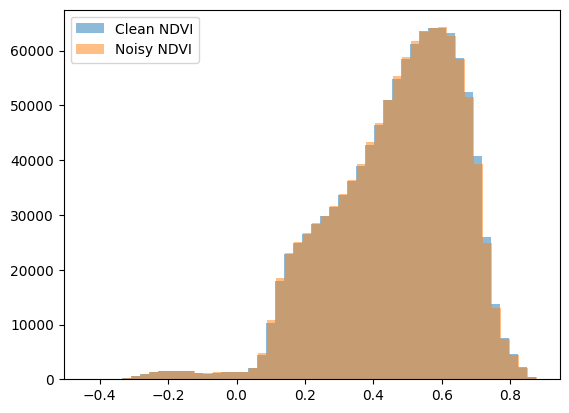

In [6]:
plt.hist(ndvi_clean.flatten(), bins=50, alpha=0.5, label="Clean NDVI")
plt.hist(ndvi_noisy.flatten(), bins=50, alpha=0.5, label="Noisy NDVI")
plt.legend()
plt.show()

# Measure shift quantitatively


In [7]:
print("Mean clean NDVI:", np.mean(ndvi_clean))
print("Mean noisy NDVI:", np.mean(ndvi_noisy))

print("Std clean NDVI:", np.std(ndvi_clean))
print("Std noisy NDVI:", np.std(ndvi_noisy))

Mean clean NDVI: 0.4660138283738062
Mean noisy NDVI: 0.4659616559972935
Std clean NDVI: 0.18703709224649678
Std noisy NDVI: 0.18713046681316306
